# Module 4 Lab 3: Textbook Problem 3.2

**CS 82A - Introduction to Data Science**

**Ramisha Tasfia**

**GitHub:** https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module4/module4_lab3.ipynb

## Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('truck.csv')
df = df.round(1)   # the file stores values like 12.39999962; the textbook values have one decimal
df.columns = ['list_price', 'best_price']   # both in $1,000s

print('Shape:', df.shape)
print(f"List price range: {df['list_price'].min()} to {df['list_price'].max()} ($1,000s)")
df.head()

Shape: (23, 2)
List price range: 12.4 to 22.4 ($1,000s)


,list_price,best_price
0,12.4,11.2
1,14.3,12.5
2,14.5,12.7
3,14.9,13.1
4,16.1,14.1


## Pearson's Correlation (Textbook Part A)

In [2]:
r = df['list_price'].corr(df['best_price'])
print(f'Pearson r = {r:.4f}')

Pearson r = 0.9985


r is about 0.999: a nearly perfect positive linear relationship. Trucks with a higher list price sell for a proportionally higher best price.

## Linear Regression (Textbook Part B)

In [3]:
slope, intercept = np.polyfit(df['list_price'], df['best_price'], 1)
print(f'best_price = {slope:.4f} x list_price + {intercept:.4f}')

residuals = df['best_price'] - (slope * df['list_price'] + intercept)
print(f'Typical miss inside the data (std of residuals): {residuals.std(ddof=2):.3f}  (${residuals.std(ddof=2) * 1000:,.0f})')
print(f'Largest miss inside the data:                    {residuals.abs().max():.3f}  (${residuals.abs().max() * 1000:,.0f})')

best_price = 0.8511 x list_price + 0.4346
Typical miss inside the data (std of residuals): 0.114  ($114)
Largest miss inside the data:                    0.373  ($373)


Each extra $1,000 of list price adds about $851 to the best price, so buyers pay roughly 85% of list plus a small fixed amount.

## Scatter Plot

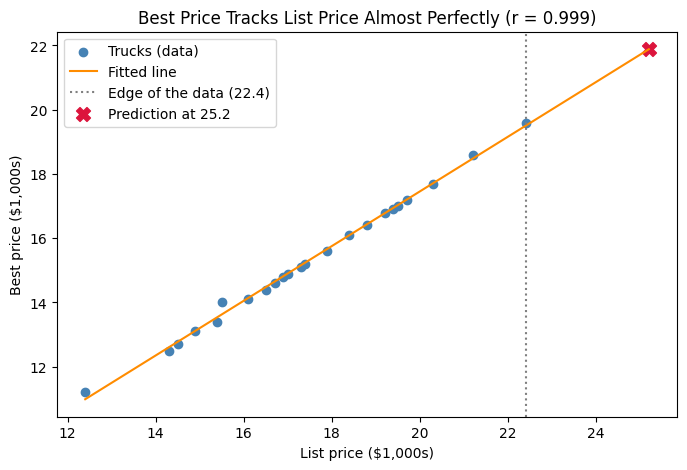

In [4]:
x_line = np.linspace(df['list_price'].min(), 25.2, 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['list_price'], df['best_price'], color='steelblue', label='Trucks (data)')
ax.plot(x_line, slope * x_line + intercept, color='darkorange', label='Fitted line')
ax.axvline(df['list_price'].max(), color='gray', linestyle=':', label='Edge of the data (22.4)')
ax.scatter([25.2], [slope * 25.2 + intercept], color='crimson', marker='X', s=100, label='Prediction at 25.2')
ax.set_title(f'Best Price Tracks List Price Almost Perfectly (r = {r:.3f})')
ax.set_xlabel('List price ($1,000s)')
ax.set_ylabel('Best price ($1,000s)')
ax.legend()
plt.show()

The points sit almost exactly on a straight line, which agrees with r = 0.999.

## Prediction (Textbook Part C)

In [5]:
new_list_price = 25.2
predicted = slope * new_list_price + intercept
print(f'Predicted best price for a list price of {new_list_price}: {predicted:.2f}  (about ${predicted * 1000:,.0f})')
print(f'How far past the data: {new_list_price - df["list_price"].max():.1f} above the highest list price in the data')

Predicted best price for a list price of 25.2: 21.88  (about $21,883)
How far past the data: 2.8 above the highest list price in the data


## Prediction Method

I used the relationship for predicting the best price based on a truck's list price because the relationship was almost perfectly linear. I used a straight line fitted to the data from all 23 trucks and entered 25.2 ($25,200) as the list price. Using this input, the prediction equation gives a best price of approximately 21.88 ($21,883).

## How Confident Is This Prediction?

The reliability of the relationship within the data is very high, with a correlation coefficient of 0.999 and a typical miss of only about $114. However, the $25,200 list price is $2,800 higher than the most expensive truck in the dataset, which was $22,400. Therefore, this prediction is an extrapolation because it falls outside the range of values used to create the regression equation. There is no indication from the data that the same discount pattern would continue for higher-priced trucks, since higher trims could be discounted differently. I would consider $21,900 a reasonable estimate, but it is less certain than a prediction made within the $12,400 to $22,400 range. The data is also based on a small sample of only 23 trucks from one source.

## AI Disclosure

**AI Disclosure:** Claude (Anthropic) was used to help explain concepts and draft initial code for this lab. All code was reviewed, retyped, and understood by me. I can explain what Pearson's r of 0.999 means, how the fitted line turns a list price into a predicted best price, and why a prediction outside the range of the data deserves less confidence.

**Key prompt:** "Help me with Module 4 Lab 3: Textbook Problem 3.2 using truck.csv."